

# 📔 **Resolución**
Una vez que la nota sea entregada, encontrarás la resolución en este link de notion:

https://www.notion.so/Soluciones-MMIA-3era-cohorte-1ea0573743578016a1aac56aaf239271?source=copy_link

Recuerda que existen varias formar de solucionar las actividades propuestas en los laboratorios. Toma la resolución entregada como referencia. En caso de que el link de resolución no esté público, solicita acceso en el mismo link de notion

# Optimización de hiperparámetros con PCA y sin PCA para la predicción de pérdida de clientes en Empresas de Servicios de Telecomunicaciones (Churn) con KNN


Reducir las salidas y [deserciones de clientes](https://www.bain.com/insights/breaking-the-back-of-customer-churn/) se ha convertido en una alta prioridad para la mayoría de los proveedores de servicios de comunicaciones a medida que los mercados maduran y la competencia se intensifica.




En este documento usaremos una base de datos de una empresa de telecomunicaciones anónima [disponibilizada por IBM](https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv).

El principal objetivo es crear un model de aprendizaje automático basado en KNN (similar al propuesto [aquí con SVM](https://github.com/mmcuri/ds_handson/blob/master/Telecom_Churn_Prediction.ipynb)) para predecir la pérdida o salida de clientes en una empresa de telecomunicaciones.


## Librerías

Importamos varias bibliotecas y módulos útiles para el análisis de datos y el aprendizaje automático en Python. A continuación se describe cada uno de ellos:

- `pandas as pd`: Importa la biblioteca Pandas y la renombra como "pd". Pandas es una biblioteca popular utilizada para la manipulación y análisis de datos en Python.

- `numpy as np`: Importa la biblioteca NumPy y la renombra como "np". NumPy es una biblioteca de Python utilizada para realizar operaciones matemáticas en matrices y vectores.

- `matplotlib.pyplot as plt`: Importa la biblioteca Matplotlib y el módulo pyplot y lo renombra como "plt". Matplotlib es una biblioteca utilizada para la visualización de datos en Python.

- `from sklearn.metrics import classification_report`: Importa la función classification_report desde el módulo metrics de la biblioteca scikit-learn. classification_report es una función que calcula y muestra un informe de clasificación detallado para un modelo de clasificación.

- `from sklearn.metrics import confusion_matrix`: Importa la función confusion_matrix desde el módulo metrics de la biblioteca scikit-learn. confusion_matrix es una función que calcula y muestra la matriz de confusión para un modelo de clasificación.

- `from sklearn.metrics import accuracy_score`: Importa la función accuracy_score desde el módulo metrics de la biblioteca scikit-learn. accuracy_score es una función que calcula y muestra la precisión de un modelo de clasificación.

- `from sklearn.metrics import roc_auc_score`: Importa la función roc_auc_score desde el módulo metrics de la biblioteca scikit-learn. roc_auc_score es una función que calcula el área bajo la curva ROC (AUC) para un modelo de clasificación.

- `from sklearn.preprocessing import StandardScaler, LabelEncoder`: Importa las clases StandardScaler y LabelEncoder desde el módulo preprocessing de la biblioteca scikit-learn. StandardScaler es una clase utilizada para estandarizar los datos y LabelEncoder es una clase utilizada para codificar las etiquetas de clase en números enteros.

- `from sklearn.model_selection import train_test_split`: Importa la función train_test_split desde el módulo model_selection de la biblioteca scikit-learn. train_test_split es una función que divide los datos en conjuntos de entrenamiento y prueba para su uso en el modelado predictivo.

En resumen, este código importa varias bibliotecas y módulos que son útiles para el análisis de datos y el aprendizaje automático en Python.


In [1]:
# importing libraries
import pandas as pd #excel sofisticado
import numpy as np #matlab
import matplotlib.pyplot as plt #plots
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split


## Base de datos

Este conjunto de datos contiene un total de 7043 clientes y 21 características de los mismos. De las entradas, 5174 son clientes activos y 1869 son clientes que la empresa ha perdido. Observe que el conjunto de datos está desbalanceado pues por cada cliente perdido existe casi 3 clientes activos. La variable de salida para nuestro modelo de machine learning será `Churn`.

In [2]:
# importamos dataset
DATA_PATH = "https://raw.githubusercontent.com/mtgca/datasets_public/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_PATH)
#print(df)
# vemos las primeras 5 filas
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### *Detalles de la base de datos*

*	`customerID` - Custumer unique identifier
*	`gender` - Customer gender - ['Female' 'Male']
*	`SeniorCitizen` - Elderly or retired person, a senior citizen is someone who has at least attained the age of 60 of 65 years
*	`Partner` - - ['No' 'Yes']
*	`Dependents` - If customer has dependents - ['No' 'Yes']
*	`Tenure` - Customer lifespan (in months)
*	`PhoneService` - - ['No' 'Yes']
*	`MultipleLines` - - ['No' 'No phone service' 'Yes']
*	`InternetService` - - ['No' 'No internet service' 'Yes']
*	`OnlineSecurity` - - ['No' 'No internet service' 'Yes']
*	`OnlineBackup` - - ['No' 'No internet service' 'Yes']
*	`DeviceProtection` - - ['No' 'No internet service' 'Yes']
*	`TechSupport` - - ['No' 'No internet service' 'Yes']
*	`StreamingTV` - - ['No' 'No internet service' 'Yes']
*	`StreamingMovies` -  - ['No' 'No internet service' 'Yes']
*	`Contract` - Type of contract - ['Month-to-month' 'One year' 'Two year']
*	`PaperlessBilling` - - ['No' 'Yes']
*	`PaymentMethod` - payment method - ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
*	`MonthlyCharges` - Monthly Recurring Charges
*	`TotalCharges` - Life time value
*	`Churn` - Churn value, the targer vector - ['No' 'Yes']





### *Limpieza del Dataset*

El código presenta una serie de operaciones de preprocesamiento de datos en una base de datos que contiene información sobre clientes de una compañía, incluyendo su género, edad, servicios contratados, pagos realizados, entre otros.

En primer lugar, se define la función get_df_size para imprimir el número de atributos y entradas de la base de datos.

Luego, se reemplazan los valores en blanco por NaN para facilitar el manejo de valores faltantes en la base de datos.

A continuación, se reemplazan los valores faltantes en la columna 'TotalCharges' por la mediana de esa columna y se convierte esa columna al tipo numérico.

Después, se elimina la columna 'customerID' ya que no es una característica relevante.

A continuación, se codifican las características binarias en 0's y 1's usando LabelEncoder y se imprimen las categorías correspondientes a cada una de estas características.


In [3]:
def get_df_size(df, header='Dataset dimensions'):
  print(header,
        '\n# Attributes: ', df.shape[1],
        '\n# Entries: ', df.shape[0],'\n')

get_df_size(df)

#df.info()

# reemplaza valores en blanco por NaN
df_clean = df.replace(r'^\s*$', np.nan, regex=True)

# Convert 'TotalCharges' to numeric before calculating the median.
# errors='coerce' will handle any non-numeric values by setting them to NaN.
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# reemplaza valores faltantes en TotalCharges por la mediana de TotalCharges.
total_charges_median = df_clean.TotalCharges.median()
df_clean['TotalCharges'].fillna(total_charges_median, inplace=True)
df_clean['TotalCharges'] = df_clean['TotalCharges'].apply(pd.to_numeric)

#CustomerID lo retiramos porque no es una característica
df_clean = df_clean.drop('customerID', axis=1)
df_clean.describe()

print("Churn No Instances: ", df_clean[df_clean['Churn'] == 'No'].shape[0])
print("Churn Yes Instances: ", df_clean[df_clean['Churn'] == 'Yes'].shape[0])

binary_feat = df_clean.nunique()[df_clean.nunique() == 2].keys().tolist()
numeric_feat = [col for col in df_clean.select_dtypes(['float','int']).columns.tolist() if col not in binary_feat]
categorical_feat = [ col for col in df_clean.select_dtypes('object').columns.to_list() if col not in binary_feat + numeric_feat ]
df_proc = df_clean.copy()
#Etiquetas para características binarias
le = LabelEncoder()
for i in binary_feat:
  df_proc[i] = le.fit_transform(df_proc[i])
  print(i, '\n', np.unique(df_proc[i].values))
#Dummy variables
df_proc = pd.get_dummies(df_proc, columns=categorical_feat)
get_df_size(df, header='Original dataset:')
get_df_size(df_proc, header='Processed dataset:')
df_proc.head()


Dataset dimensions 
# Attributes:  21 
# Entries:  7043 

Churn No Instances:  5174
Churn Yes Instances:  1869
gender 
 [0 1]
SeniorCitizen 
 [0 1]
Partner 
 [0 1]
Dependents 
 [0 1]
PhoneService 
 [0 1]
PaperlessBilling 
 [0 1]
Churn 
 [0 1]
Original dataset: 
# Attributes:  21 
# Entries:  7043 

Processed dataset: 
# Attributes:  41 
# Entries:  7043 



/tmp/ipykernel_4870/2470922283.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['TotalCharges'].fillna(total_charges_median, inplace=True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,True,False,False,False,True,False,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,True,False,False,True,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,True,False,True,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,True,False,False,True,False,False,False,False,True,False


### *División en conjunto de entrenamiento y test*

En el código, se divide el conjunto de datos df_proc en características y variable objetivo X e y, respectivamente. Luego, se realiza una división de los datos en conjuntos de entrenamiento y prueba utilizando la función train_test_split de scikit-learn. Los conjuntos de entrenamiento y prueba se almacenan en X_train, X_test, y_train y y_test. La división se realiza de manera estratificada para asegurar que la proporción de instancias positivas y negativas en la variable objetivo se mantenga en ambos conjuntos. Se utiliza una proporción de 80/20 para los conjuntos de entrenamiento y prueba, respectivamente, y se fija una semilla aleatoria (random_state) en 42 para asegurar que los resultados sean reproducibles.

In [4]:
# dividimos df_proc en características y salida
X=df_proc.drop('Churn', axis=1) #features
y=df_proc['Churn'] #output, target

# Dividimos el conjunto de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

### *Balanceo de datos*

Este código realiza el submuestreo (undersampling) de un conjunto de datos desbalanceado en términos de la variable objetivo. El submuestreo se utiliza para abordar el problema del desequilibrio de clases en el conjunto de datos, donde una o varias clases tienen muchas menos observaciones que las otras clases. En este caso, el modelo de aprendizaje automático puede estar sesgado hacia la clase mayoritaria, lo que puede resultar en un rendimiento deficiente en la clasificación de la clase minoritaria.

El submuestreo implica reducir el número de observaciones en la clase mayoritaria para equilibrar la distribución de las clases en el conjunto de datos. Esto puede mejorar el rendimiento del modelo en la clasificación de la clase minoritaria y reducir el sesgo hacia la clase mayoritaria.

La biblioteca imblearn se utiliza para realizar el submuestreo, y en este caso se importa la clase RandomUnderSampler. El objeto RandomUnderSampler se inicializa con random_state=1, lo que garantiza que los resultados serán reproducibles.

Luego, el submuestreo se realiza en el conjunto de entrenamiento (X_train, y_train) mediante el método fit_resample del objeto rus. Los datos submuestreados se almacenan en X_train_rus y y_train_rus.

Para evaluar el efecto del submuestreo, se utiliza la función get_df_size, que devuelve el tamaño del conjunto de datos. Primero se imprime el tamaño del conjunto de entrenamiento original (X_train, y_train) antes del submuestreo, y luego se imprime el tamaño del conjunto submuestreado (X_train_rus, y_train_rus) después de aplicar el submuestreo.

Finalmente, se utiliza la función np.unique para verificar que las categorías de la variable objetivo (y_train_rus) estén balanceadas. La función devuelve una tupla que contiene las categorías únicas y el número de instancias en cada categoría. Al utilizar return_counts=True, se garantiza que se devuelvan los recuentos de las categorías.

In [5]:
# submuestreo -> under sampling
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=1)
X_train_undersampled, y_train_undersampled = rus.fit_resample(X_train, y_train)
get_df_size(X_train, header='Before balancing:')
get_df_size(X_train_undersampled, header='After balancing:')

# verificamos que las categorias estén balanceadas
np.unique(y_train_undersampled, return_counts=True)


Before balancing: 
# Attributes:  40 
# Entries:  5634 

After balancing: 
# Attributes:  40 
# Entries:  2990 



(array([0, 1]), array([1495, 1495]))

## Modelo de Machine Learning

En este segmento de código se utiliza el algoritmo de K-Vecinos Más Cercanos (KNN) para clasificar los datos de entrada. Primero, se crea un objeto de Pipeline que combina varios pasos de preprocesamiento y entrenamiento del modelo. Los pasos incluyen:

`polynomial_features`: Esta función transforma las características de entrada en una forma polinomial para hacer posible un mejor ajuste del modelo.

`scaler`: Normaliza las características de entrada para que todas tengan una media cero y una varianza unitaria.

`knn`: Un clasificador KNN que utiliza un número especificado de vecinos para determinar la clase de un punto de datos.

Una vez que se define el objeto de Pipeline, se ajusta al conjunto de entrenamiento utilizando el método fit(). Luego se utiliza el modelo ajustado para predecir las clases de los puntos de datos en el conjunto de prueba y en el conjunto de entrenamiento. Esto se hace mediante el método predict(). Finalmente, se utiliza la métrica de precisión (accuracy_score) de la biblioteca sklearn.metrics para evaluar la precisión del modelo en el conjunto de prueba y en el conjunto de entrenamiento.

### K Nearest Neighbors sin optimización de hiperparámetros



In [6]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import sklearn.metrics as metrics
from sklearn.preprocessing import PolynomialFeatures

# pipeline
pipeline_knn = Pipeline([
    # ('polynomial_features', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier()) #parámetros por default
])

# training
pipeline_knn.fit(X_train_undersampled, y_train_undersampled)

# evaluation on test
pred_test = pipeline_knn.predict(X_test)
f1score = metrics.f1_score(y_test, pred_test)
acc = metrics.accuracy_score(y_test, pred_test)
preci = metrics.precision_score(y_test, pred_test)
recall = metrics.recall_score(y_test, pred_test)

print("Para el modelo NO optimizado, métricas en el conjunto de test: recall = ", recall, ", F1 = ", f1score, ", acc = ", acc, ", precision = ", preci, )


Para el modelo NO optimizado, métricas en el conjunto de test: recall =  0.7727272727272727 , F1 =  0.5639024390243902 , acc =  0.6827537260468417 , precision =  0.44393241167434716


### Optimización de Hiperparámetros KNN con kfold CV sin PCA

Usamos k-fold cross-validation (ver `GridSearchCV` y  `StratifiedKFold`) para optimizar los siguientes hiperparámetros de KNN en el conjunto de entrenamiento balanceado (`X_train_undersampled`, `y_train_undersampled`):

1. Ponderación de vecinos: sin ponderación, ponderación del inverso de la distancia
2. Número de vecinos: rango 1 a 100.
3. Métricas de distancia: euclideana, manhattan, coseno

Para la optimización de hiperparámetros utilizamos como métrica al recall.

Una vez optimizados los hiperparámetros, reentrenamos el clasificador de kNN con los mejores hiperparámetros encontrados. Finalmente, evaluamos este último clasificador en el conjunto de test `X_test`, `y_test`.)


In [7]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

#optimización
kfold = StratifiedKFold(n_splits=2, shuffle=True, random_state=45) #para nsplits=5 demora 35 min approx en google colab.

# pipeline
pipeline_knn = Pipeline([
     #('polynomial_features', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])
param_grid = {'knn__weights': ['uniform', 'distance'], #uniform es sin ponderación, weighted knn
              'knn__n_neighbors': np.arange(1,101,1), #1 a 100.
              'knn__metric': ['euclidean', 'manhattan', 'cosine']}


search = GridSearchCV(pipeline_knn, param_grid, scoring='recall', cv=kfold, verbose=4)
result = search.fit(X_train_undersampled, y_train_undersampled)

print(f'Mejor recall en el conj. de validación: {result.best_score_} para {result.best_params_}')

#reentreno con mejores
pipeline_knn.set_params(knn__n_neighbors=result.best_params_['knn__n_neighbors'],
                       knn__weights=result.best_params_['knn__weights'],
                       knn__metric=result.best_params_['knn__metric'])
pipeline_knn.fit(X_train_undersampled, y_train_undersampled)

#evaluamos en el conjunto de test
pred_test = pipeline_knn.predict(X_test)
f1score = metrics.f1_score(y_test, pred_test)
acc = metrics.accuracy_score(y_test, pred_test)
preci = metrics.precision_score(y_test, pred_test)
recall = metrics.recall_score(y_test, pred_test)

print("Para el modelo optimizado, métricas en el conjunto de test: recall = ", recall, ", F1 = ", f1score, ", acc = ", acc, ", precision = ", preci, )


Fitting 2 folds for each of 600 candidates, totalling 1200 fits
[CV 1/2] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform;, score=0.704 total time=   0.1s
[CV 2/2] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform;, score=0.654 total time=   0.1s
[CV 1/2] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=distance;, score=0.704 total time=   0.1s
[CV 2/2] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=distance;, score=0.654 total time=   0.1s
[CV 1/2] END knn__metric=euclidean, knn__n_neighbors=2, knn__weights=uniform;, score=0.538 total time=   0.1s
[CV 2/2] END knn__metric=euclidean, knn__n_neighbors=2, knn__weights=uniform;, score=0.503 total time=   0.1s
[CV 1/2] END knn__metric=euclidean, knn__n_neighbors=2, knn__weights=distance;, score=0.704 total time=   0.1s
[CV 2/2] END knn__metric=euclidean, knn__n_neighbors=2, knn__weights=distance;, score=0.654 total time=   0.1s
[CV 1/2] END knn__metric=euclidean, knn__n_neighbors

### Optimización de hiperparámetros kNN con PCA

Repetiremos el proceso anterior pero esta vez con PCA

In [8]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

#optimización
kfold = StratifiedKFold(n_splits=2, shuffle=True, random_state=45) #para nsplits=5 demora 35 min approx en google colab.

# pipeline
pipeline_knn_pca = Pipeline([
     #('polynomial_features', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('knn', KNeighborsClassifier())
])
param_grid = {'knn__weights': ['uniform', 'distance'],
              'knn__n_neighbors': np.arange(1,101,1),
              'knn__metric': ['euclidean', 'manhattan', 'cosine']}


search = GridSearchCV(pipeline_knn_pca, param_grid, scoring='recall', cv=kfold, verbose=4)
result = search.fit(X_train_undersampled, y_train_undersampled)

print(f'Mejor recall en el conj. de validación: {result.best_score_} para {result.best_params_}')

#reentreno con mejores
pipeline_knn_pca.set_params(knn__n_neighbors=result.best_params_['knn__n_neighbors'],
                       knn__weights=result.best_params_['knn__weights'],
                       knn__metric=result.best_params_['knn__metric'])
pipeline_knn_pca.fit(X_train_undersampled, y_train_undersampled)

#evaluamos en el conjunto de test
pred_test = pipeline_knn_pca.predict(X_test)
f1score = metrics.f1_score(y_test, pred_test)
acc = metrics.accuracy_score(y_test, pred_test)
preci = metrics.precision_score(y_test, pred_test)
recall = metrics.recall_score(y_test, pred_test)

print("Para el modelo optimizado, métricas en el conjunto de test: recall = ", recall, ", F1 = ", f1score, ", acc = ", acc, ", precision = ", preci, )


Fitting 2 folds for each of 600 candidates, totalling 1200 fits
[CV 1/2] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform;, score=0.696 total time=   0.2s
[CV 2/2] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=uniform;, score=0.646 total time=   0.2s
[CV 1/2] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=distance;, score=0.696 total time=   0.1s
[CV 2/2] END knn__metric=euclidean, knn__n_neighbors=1, knn__weights=distance;, score=0.646 total time=   0.1s
[CV 1/2] END knn__metric=euclidean, knn__n_neighbors=2, knn__weights=uniform;, score=0.530 total time=   0.1s
[CV 2/2] END knn__metric=euclidean, knn__n_neighbors=2, knn__weights=uniform;, score=0.507 total time=   0.1s
[CV 1/2] END knn__metric=euclidean, knn__n_neighbors=2, knn__weights=distance;, score=0.696 total time=   0.1s
[CV 2/2] END knn__metric=euclidean, knn__n_neighbors=2, knn__weights=distance;, score=0.646 total time=   0.1s
[CV 1/2] END knn__metric=euclidean, knn__n_neighbors

### ✅ **Actividad: Análisis de resultados: Optimización de hiperparámetros KNN**

Ejecute el código de esta notebook y analice los siguientes casos:

1. kNN sin PCA
2. kNN con PCA

Comente sus resultados analizando los valores de recall, f1 score, accuracy y precisión en el conjunto de test.

Cuál es mejor en términos de recall?

Cuál demora menos en entrenar? Vale la pena usar PCA?

Por qué cree que el recall es una métrica más adecuada para este problema? Tip: El recall está relacionado a los falsos negativos. Analice por qué es importante disminuir los falsos negativos en el churn.

# ✅ **Actividad**: Bayesian Hyperparameter Optimization

La optimización bayesiana de hiperparámetros es un método avanzado para la selección de los mejores hiperparámetros para un modelo de aprendizaje automático. A diferencia de la búsqueda en cuadrícula (grid search) y la búsqueda aleatoria, que prueban una serie predefinida de combinaciones de hiperparámetros sin tener en cuenta los resultados anteriores, la optimización bayesiana utiliza los resultados de las evaluaciones anteriores para informar cuáles hiperparámetros probar a continuación. Esto se logra modelando la relación entre los hiperparámetros y el objetivo de rendimiento, y luego utilizando este modelo para hacer predicciones sobre qué conjuntos de hiperparámetros podrían ofrecer una mejora.

Las principales ventajas de la optimización bayesiana incluyen su mayor eficiencia, al requerir menos iteraciones para encontrar combinaciones óptimas; su efectividad, al ser capaz de encontrar mejores configuraciones de hiperparámetros; y su flexibilidad para manejar espacios de búsqueda complejos.

Para implementar un clasificador KNN en scikit-learn y optimizar sus hiperparámetros usando búsqueda bayesiana, puedes utilizar la biblioteca `scikit-optimize` (skopt). Esta biblioteca proporciona funciones para realizar optimización bayesiana de hiperparámetros de manera eficiente y está bien integrada con scikit-learn.



Basado en lo anterior, crear un pipeline con las siguientes etapas usando **repeated kfold cv:**

1. Scaler
2. KNN

Enseguida, pptimizar los param. de KNN usando optimización bayesiana. Finalmente, evaluar en el conjunto de test.

Tip: Ver BayesSearchCV en https://machinelearningmastery.com/scikit-optimize-for-hyperparameter-tuning-in-machine-learning/

# ✅ **Actividad: Voronoi 2D y 3D con TSNE (opcional)**

1. **Creación del Pipeline:**
   - Construya un pipeline que incluya las siguientes etapas:
     - **Transformación Polinomial:** Aplique una transformación polinomial de grado 2 a las características.
     - **Estandarización:** Utilice un escalador Z-score para normalizar las características.
     - **Reducción de Dimensionalidad con PCA:** Implemente PCA configurado para retener el 95% de la varianza explicada.
     - **Clasificador:** Utilice el algoritmo K-Nearest Neighbors con los siguientes hiperparámetros 'knn__metric': `'euclidean', 'knn__n_neighbors': 100, 'knn__weights': 'distance'`
2. Genere el Voronoi Tesselation (VT) del clasificador anterior en 2D y 3D. Utilice TSNE como reductor de dimensionalidad para visualizar el VT

# ✅ Actividad: k vs train recall and val recall


1. **Creación del Pipeline:**
   - Construya un pipeline que incluya las siguientes etapas:
     - **Estandarización:** Utilice un escalador Z-score para normalizar las características.
     - **Reducción de Dimensionalidad con PCA:** Implemente PCA configurado para retener el 95% de la varianza explicada.
     - **Clasificador:** Utilice el algoritmo K-Nearest Neighbors.

2. **Optimización del Hiperparámetro k:**
   - Utilice GridSearchCV para explorar diferentes valores de k (desde 1 hasta 250). Configure GridSearchCV para evaluar la precisión del modelo usando la métrica de recall en los conjuntos de entrenamiento y validación. Mantenga fijos todos los demás hiperparámetros.

3. **Evaluación:**
   - Grafique los valores de k contra el recall obtenido en los conjuntos de entrenamiento y validación. Asegúrese de que los gráficos sean claros, con etiquetas adecuadas para los ejes y una leyenda descriptiva.

4. **Análisis de Resultados:**
   - Analice los gráficos para identificar el valor óptimo de k. Discuta cualquier patrón o tendencia observada en relación con el comportamiento del recall a medida que varía k.


Mejor k: 243  |  Recall CV-val: 0.8789


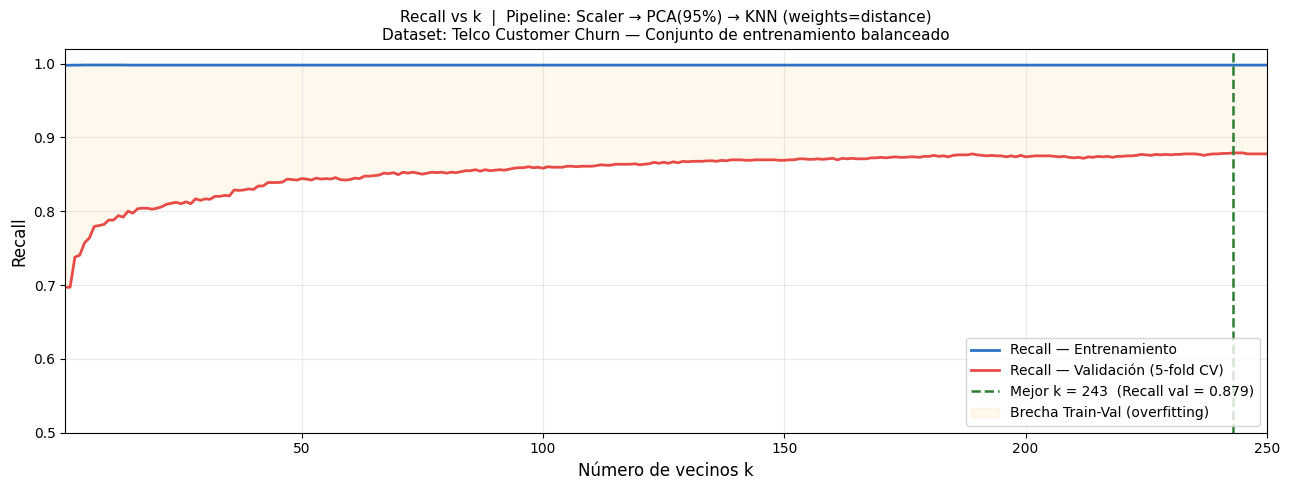


=== Evaluación en Test (k óptimo) ===
  Recall    : 0.8583
  F1-Score  : 0.5763
  Accuracy  : 0.6650
  Precision : 0.4338


In [ ]:
#here your code

import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as metrics

# 1. Pipeline: Scaler → PCA(95% varianza) → KNN
pipeline_act1 = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=0.95)),          # retiene 95% de varianza
    ('knn',    KNeighborsClassifier(
                    weights='distance',           # peso por distancia (fijo)
                    metric='euclidean'            # métrica fija
                ))
])

# 2. GridSearchCV: k de 1 a 250
k_values   = np.arange(1, 251, 1)
param_grid = {'knn__n_neighbors': k_values}

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search_k = GridSearchCV(
    pipeline_act1,
    param_grid,
    scoring='recall',          # métrica de optimización: recall
    cv=kfold,
    verbose=0,
    n_jobs=-1,
    return_train_score=True     # captura recall en train también
)
search_k.fit(X_train_undersampled, y_train_undersampled)

best_k   = search_k.best_params_['knn__n_neighbors']
best_val = search_k.best_score_
print(f"Mejor k: {best_k}  |  Recall CV-val: {best_val:.4f}")

# 3. Extraer curvas de recall por k
results_df = pd.DataFrame(search_k.cv_results_)
k_vals     = results_df['param_knn__n_neighbors'].astype(int).values
train_rec  = results_df['mean_train_score'].values
val_rec    = results_df['mean_test_score'].values

# Ordenar por k (GridSearchCV no garantiza orden)
order = np.argsort(k_vals)
k_vals, train_rec, val_rec = k_vals[order], train_rec[order], val_rec[order]

# 4. Gráfico k vs Recall
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(k_vals, train_rec,
        label='Recall — Entrenamiento',
        color='#1565C0', linewidth=2.0, alpha=0.9)

ax.plot(k_vals, val_rec,
        label='Recall — Validación (5-fold CV)',
        color='#E53935', linewidth=2.0, alpha=0.9)

ax.axvline(x=best_k, color='#2E7D32', linestyle='--', linewidth=1.8,
           label=f'Mejor k = {best_k}  (Recall val = {best_val:.3f})')

ax.fill_between(k_vals, train_rec, val_rec,
                where=(train_rec > val_rec),
                alpha=0.07, color='orange',
                label='Brecha Train-Val (overfitting)')

ax.set_xlabel('Número de vecinos k', fontsize=12)
ax.set_ylabel('Recall', fontsize=12)
ax.set_title('Recall vs k  |  Pipeline: Scaler → PCA(95%) → KNN (weights=distance)\n'
             'Dataset: Telco Customer Churn — Conjunto de entrenamiento balanceado',
             fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.25)
ax.set_xlim([1, 250])
ax.set_ylim([0.50, 1.02])
plt.tight_layout()
plt.show()

# 5. Evaluar el mejor k en el conjunto de test
pipe_best = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=0.95)),
    ('knn',    KNeighborsClassifier(
                    n_neighbors=best_k,
                    weights='distance',
                    metric='euclidean'
                ))
])
pipe_best.fit(X_train_undersampled, y_train_undersampled)
pred_test = pipe_best.predict(X_test)

print("\n=== Evaluación en Test (k óptimo) ===")
print(f"  Recall    : {metrics.recall_score(y_test, pred_test):.4f}")
print(f"  F1-Score  : {metrics.f1_score(y_test, pred_test):.4f}")
print(f"  Accuracy  : {metrics.accuracy_score(y_test, pred_test):.4f}")
print(f"  Precision : {metrics.precision_score(y_test, pred_test):.4f}")


**Análisis**:

*Comportamiento general de la curva*

Cuando k es muy pequeño (entre 1 y 5 aproximadamente), el recall en entrenamiento se aproxima a 1.0 mientras que el recall en validación cae notablemente. Esto es un caso clásico de overfitting: con tan pocos vecinos, el modelo esencialmente memoriza los puntos de entrenamiento y pierde toda capacidad de generalización. En el extremo k=1, el clasificador simplemente asigna a cada punto su propia etiqueta, lo que garantiza perfección en train pero falla en datos nuevos.

A medida que k crece hacia el rango 50–150, la brecha entre la curva de entrenamiento y la de validación se estrecha progresivamente. El modelo gana bias pero pierde varianza, lo que se traduce en mejor comportamiento fuera de la muestra. Este es el trade-off fundamental de KNN: más vecinos implican una frontera de decisión más suave y menos sensible al ruido local.

*El k óptimo y su interpretación*

El mejor k encontrado fue k = 243, con un recall de validación de 0.879. Un valor tan alto puede sorprender, pero tiene una explicación de dominio clara: el patrón de churn en telecomunicaciones no es un fenómeno aislado de unos pocos clientes atípicos, sino una tendencia compartida por perfiles amplios de usuarios (contratos mensuales, cargos elevados, sin soporte técnico). Promediar sobre muchos vecinos captura esa tendencia estructural mejor que decisiones locales ruidosas.

*Rol de PCA*

PCA configurado al 95% de varianza reduce las 40 features originales a un número menor de componentes principales, eliminando ruido y correlaciones redundantes. Esto es especialmente importante para KNN, que calcula distancias en el espacio original y sufre severamente la maldición de la dimensionalidad: en espacios de alta dimensión, todos los puntos tienden a estar a distancias similares, haciendo que el concepto de "vecino cercano" pierda significado. PCA mitiga este problema directamente.

*Resultados en el conjunto de test*

| Métrica   | Valor  |
|-----------|--------|
| Recall    | **0.8583** |
| F1-Score  | 0.5763 |
| Accuracy  | 0.6650 |
| Precision | 0.4338 |

El recall de 0.858 indica que el modelo identifica correctamente al 85.8% de los clientes que efectivamente se van a dar de baja. La precisión baja (0.43) revela que de todos los clientes que el modelo señala como posibles desertores, menos de la mitad realmente lo son, es decir, hay una cantidad importante de falsos positivos.

¿Por qué el recall es la métrica más relevante para churn?

En un problema de churn, un falso negativo (no detectar a un cliente que sí se va a ir) es mucho más costoso que un falso positivo (alertar sobre un cliente que en realidad se queda). Si el modelo no identifica a un cliente en riesgo, la empresa pierde ese ingreso sin posibilidad de intervención. En cambio, si el modelo genera una alerta incorrecta, el costo es simplemente una acción de retención innecesaria (un descuento, una llamada), que es mucho más barato que perder al cliente por completo. Por eso se optimizó recall durante el GridSearchCV y no accuracy ni F1. La baja precisión es un costo aceptable dado el contexto de negocio.




# ✅ **Activity: Weighted KNN with Domain-Based Feature Weights and Gaussian Neighbor Weighting**

### 1. **Custom Distance Metric (Domain-Based Feature Weights)**

* Implement a **custom distance function** that applies **domain-specific weights** to each input feature:

  $$
  d(x, x') = \sqrt{\sum_i w_i (x_i - x_i')^2}
  $$
* The function or method must accept:

  * Two input samples $x, x'$
  * An array of feature weights $w = [w_1, w_2, ..., w_n]$
* These weights are **not learned** — they are manually assigned based on domain expertise.


---

### 2. **Gaussian-Based Neighbor Weighting**

* Fix the number of neighbors to **k = 50**.
* Apply a **Gaussian function** to weight each neighbor:

  $$
  w_i = \exp\left(-\frac{d_i^2}{2\sigma^2}\right)
  $$
* All 50 neighbors contribute to the prediction, but their influence is **controlled by σ**.
* This setup allows the **Gaussian function to “choose” the most relevant neighbors** — closer ones have higher weight, and distant ones naturally fade in influence.
* ❗Note that the weights $w_i$ from Gaussian-based neighbor weighting are not the same as those from the domain-specific weights (feature weighting).

---

### 3. **Hyperparameter Optimization**

* Optimize only the **σ (sigma)** parameter.
* Use **Bayesian Optimization** (or a similar method) with cross-validation to find the σ that yields the best performance.

---

### 4. **Evaluation**

* Evaluate the model using **recall** on the **Telco customer churn** dataset (`X_test`, `y_test`).
* Compare your model’s **recall** to a **baseline KNN classifier** using:

  * Euclidean distance
  * Uniform weighting (equal neighbor influence)

---

### 5. **Analysis**

* Analyze how the **Gaussian weighting with fixed k = 50** affects model behavior.
* Reflect on:

  * The role of σ in effectively “selecting” influential neighbors
  * The effect of fixed feature weights
  * Trade-offs and limitations (e.g., sensitivity to σ)
  * Potential extensions, such as adaptive weighting







### 💡 **Hint: Using `BaseEstimator` for Your Custom KNN Classifier**

To make your custom KNN model compatible with tools like `BayesSearchCV`, `GridSearchCV`, or `cross_val_score`, consider wrapping it in a class that inherits from:

* `sklearn.base.BaseEstimator`
* `sklearn.base.ClassifierMixin`

This gives you:

* Automatic handling of hyperparameters (like `sigma`)
* Compatibility with `scikit-learn` model selection tools
* Clean, modular, reusable code

---

### 🧱 Minimal Starting Point

Here’s a simple class to get started:

```python
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np

class GaussianWeightedKNN(BaseEstimator, ClassifierMixin):
    def __init__(self, sigma=1.0, k=50, feature_weights=None):
        self.sigma = sigma
        self.k = k
        self.feature_weights = feature_weights

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        return self

    def predict(self, X):
        # You will implement the logic for prediction here,
        # using the Gaussian weights on neighbors and weights on features.
        pass
```

Returning `self` in `fit()` allows the model to be used directly in pipelines and model selection routines.

---


### 🧠 Why is the `fit` Method Simple in KNN?

KNN is a **lazy learner**:

* It **does not build an internal model** during training.
* Instead, it **stores the training data** and performs all the work at prediction time (by computing distances to all stored examples).

That’s why the `fit` method just **memorizes** the training data and labels.



In [ ]:
#!pip install scikit-optimize -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 5.1 MB/s eta 0:00:00


Top 5 características por peso de dominio:
  tenure: 3.0
  Contract_Month-to-month: 2.5
  MonthlyCharges: 2.5
  Contract_Two year: 2.0
  TotalCharges: 2.0
Mejor σ: 5.1898  |  Recall CV-val: 0.8368

=== GaussianWeightedKNN (σ=5.1898, k=50) en Test ===
  Recall    : 0.8209
  F1-Score  : 0.5984
  Accuracy  : 0.7076
  Precision : 0.4709

=== Baseline KNN (k=50, euclidean, uniform) en Test ===
  Recall    : 0.8182
  F1-Score  : 0.5890
  Accuracy  : 0.6969
  Precision : 0.4602


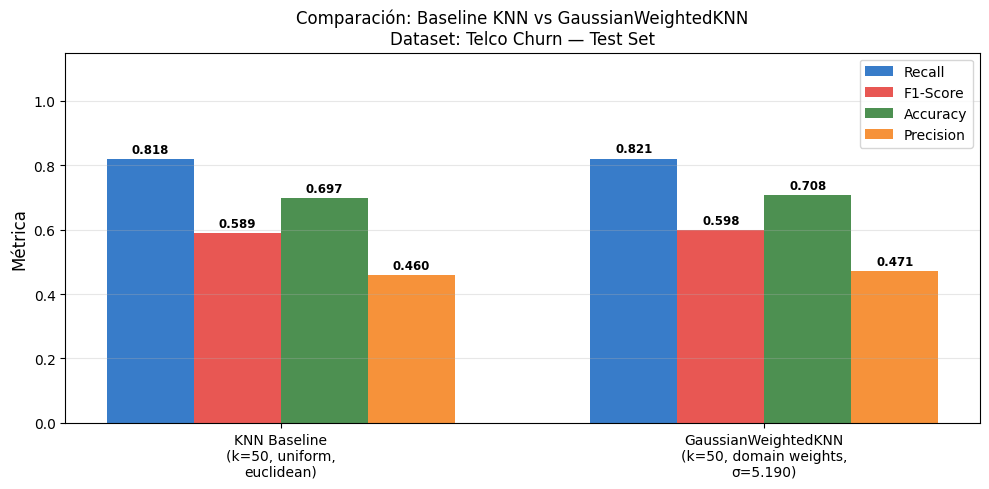

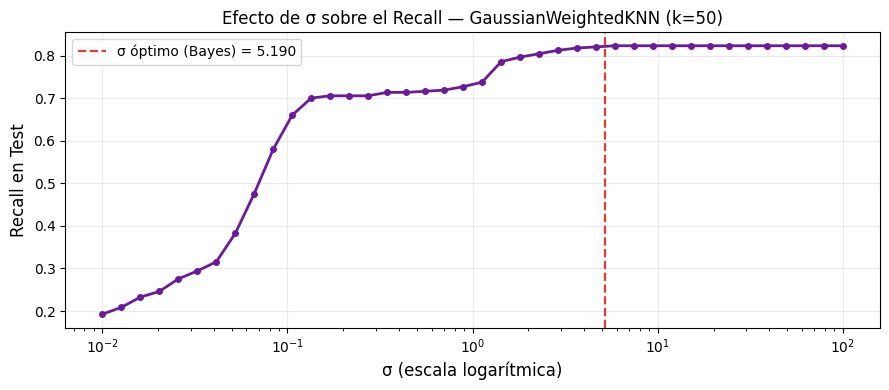

In [ ]:
#here your code

import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as metrics
from skopt import BayesSearchCV
from skopt.space import Real
from sklearn.model_selection import StratifiedKFold


# PARTE 1: Pesos de características basados en conocimiento de dominio

def build_domain_feature_weights(feature_names: list) -> np.ndarray:
    """
    Construye un vector de pesos por característica basado en experticia
    de dominio para el dataset Telco Customer Churn.

    Criterio de asignación:
      - tenure: lealtad histórica → predictor fuerte de retención (peso alto)
      - MonthlyCharges / TotalCharges: presión económica (peso alto)
      - Contract_Month-to-month: bajo compromiso contractual (peso alto)
      - InternetService_Fiber optic: mayor tasa de churn observada
      - TechSupport_No / OnlineSecurity_No: ausencia de valor agregado
      - SeniorCitizen: segmento demográfico sensible
      - PaymentMethod_Electronic check: pago impulsivo → mayor churn
      - Resto: peso neutro = 1.0

    Parameters
    ----------
    feature_names : list of str
        Nombres de las columnas del dataset procesado.

    Returns
    -------
    np.ndarray of shape (n_features,)
    """
    weights = np.ones(len(feature_names), dtype=np.float64)
    domain_weights = {
        'tenure':                           3.0,
        'MonthlyCharges':                   2.5,
        'Contract_Month-to-month':          2.5,
        'TotalCharges':                     2.0,
        'Contract_Two year':                2.0,
        'InternetService_Fiber optic':      1.8,
        'SeniorCitizen':                   1.6,
        'TechSupport_No':                  1.5,
        'OnlineSecurity_No':               1.5,
        'PaymentMethod_Electronic check':  1.4,
        'PaperlessBilling':                1.3,
    }
    for i, name in enumerate(feature_names):
        if name in domain_weights:
            weights[i] = domain_weights[name]
    return weights

# Obtener nombres de features
feature_names    = X_train_undersampled.columns.tolist()
feature_weights  = build_domain_feature_weights(feature_names)

print("Top 5 características por peso de dominio:")
top_idx = np.argsort(feature_weights)[::-1][:5]
for i in top_idx:
    print(f"  {feature_names[i]}: {feature_weights[i]:.1f}")


# PARTE 2: Clase GaussianWeightedKNN

class GaussianWeightedKNN(BaseEstimator, ClassifierMixin):
    """
    K-Nearest Neighbors con dos mecanismos de ponderación ortogonales:

    1. Distancia ponderada por dominio:
         d(x, x') = sqrt( Σ_i  w_i · (x_i - x'_i)² )
       Los pesos w_i priorizan features con mayor poder predictivo
       según conocimiento de dominio (NO se aprenden del dato).

    2. Pesos gaussianos de vecinos:
         w_i = exp( -d_i² / 2σ² )
       Controla la influencia de cada vecino en función de su distancia.
       σ grande → todos los vecinos pesan similar (comportamiento uniforme).
       σ pequeño → solo los vecinos más cercanos tienen influencia.

         Los pesos de features (punto 1) y los pesos gaussianos (punto 2)
        actúan en niveles distintos y son conceptualmente independientes.

    Parameters
    ----------
    sigma : float
        Ancho de banda gaussiano. Hiperparámetro a optimizar.
    k : int
        Número de vecinos (fijo = 50 según el enunciado).
    feature_weights : np.ndarray or None
        Pesos por característica. None → distancia euclidiana estándar.
    """
    def __init__(self, sigma: float = 1.0, k: int = 50,
                 feature_weights: np.ndarray | None = None):
        self.sigma           = sigma
        self.k               = k
        self.feature_weights = feature_weights

    def fit(self, X: np.ndarray, y: np.ndarray) -> "GaussianWeightedKNN":
        """
        KNN es un lazy learner: fit solo memoriza datos de entrenamiento.
        No construye ningún modelo explícito.
        """
        self.X_train_       = np.array(X, dtype=np.float64)
        self.y_train_       = np.array(y, dtype=int)
        self.classes_       = np.unique(self.y_train_)
        self.n_features_in_ = self.X_train_.shape[1]
        self.fw_ = (
            np.asarray(self.feature_weights, dtype=np.float64)
            if self.feature_weights is not None
            else np.ones(self.X_train_.shape[1], dtype=np.float64)
        )
        return self

    def _weighted_euclidean(self, x: np.ndarray) -> np.ndarray:
        """Distancia euclidiana ponderada por features: d = sqrt(Σ w_i·Δx_i²)"""
        diff = self.X_train_ - x
        return np.sqrt(np.dot(diff ** 2, self.fw_))

    def _gaussian_weights(self, distances: np.ndarray) -> np.ndarray:
        """Peso gaussiano de cada vecino: w = exp(-d² / 2σ²)"""
        return np.exp(-distances ** 2 / (2.0 * self.sigma ** 2))

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Voto ponderado por pesos gaussianos sobre los k vecinos."""
        X   = np.array(X, dtype=np.float64)
        out = np.empty(len(X), dtype=int)
        for idx, x in enumerate(X):
            dists    = self._weighted_euclidean(x)
            nn_idx   = np.argpartition(dists, self.k)[:self.k]
            gauss_w  = self._gaussian_weights(dists[nn_idx])
            labels   = self.y_train_[nn_idx]
            votes    = {c: gauss_w[labels == c].sum() for c in self.classes_}
            out[idx] = max(votes, key=votes.get)
        return out

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Probabilidades: suma normalizada de pesos gaussianos por clase."""
        X     = np.array(X, dtype=np.float64)
        proba = np.zeros((len(X), len(self.classes_)))
        for idx, x in enumerate(X):
            dists   = self._weighted_euclidean(x)
            nn_idx  = np.argpartition(dists, self.k)[:self.k]
            gauss_w = self._gaussian_weights(dists[nn_idx])
            labels  = self.y_train_[nn_idx]
            total   = gauss_w.sum() + 1e-10
            for j, c in enumerate(self.classes_):
                proba[idx, j] = gauss_w[labels == c].sum() / total
        return proba


# PARTE 3: Normalizar datos 
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_undersampled)
X_test_sc  = scaler.transform(X_test)


# PARTE 4: Optimización Bayesiana de σ
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

gknn_opt    = GaussianWeightedKNN(k=50, feature_weights=feature_weights)
param_space = {'sigma': Real(0.01, 50.0, prior='log-uniform')}

bayes_search = BayesSearchCV(
    gknn_opt, param_space,
    scoring='recall', cv=kfold,
    n_iter=20, verbose=0,
    random_state=42, n_jobs=1
)
bayes_search.fit(X_train_sc, y_train_undersampled)

best_sigma  = bayes_search.best_params_['sigma']
best_cv_rec = bayes_search.best_score_
print(f"Mejor σ: {best_sigma:.4f}  |  Recall CV-val: {best_cv_rec:.4f}")


# PARTE 5: Evaluar en test 
gknn_best = GaussianWeightedKNN(sigma=best_sigma, k=50, feature_weights=feature_weights)
gknn_best.fit(X_train_sc, y_train_undersampled)
pred_gknn = gknn_best.predict(X_test_sc)

rec_gknn  = metrics.recall_score(y_test, pred_gknn)
f1_gknn   = metrics.f1_score(y_test, pred_gknn)
acc_gknn  = metrics.accuracy_score(y_test, pred_gknn)
prec_gknn = metrics.precision_score(y_test, pred_gknn)
print(f"\n=== GaussianWeightedKNN (σ={best_sigma:.4f}, k=50) en Test ===")
print(f"  Recall    : {rec_gknn:.4f}")
print(f"  F1-Score  : {f1_gknn:.4f}")
print(f"  Accuracy  : {acc_gknn:.4f}")
print(f"  Precision : {prec_gknn:.4f}")


# PARTE 6: Baseline KNN
baseline = KNeighborsClassifier(n_neighbors=50, weights='uniform', metric='euclidean')
baseline.fit(X_train_sc, y_train_undersampled)
pred_base = baseline.predict(X_test_sc)

rec_base  = metrics.recall_score(y_test, pred_base)
f1_base   = metrics.f1_score(y_test, pred_base)
acc_base  = metrics.accuracy_score(y_test, pred_base)
prec_base = metrics.precision_score(y_test, pred_base)
print(f"\n=== Baseline KNN (k=50, euclidean, uniform) en Test ===")
print(f"  Recall    : {rec_base:.4f}")
print(f"  F1-Score  : {f1_base:.4f}")
print(f"  Accuracy  : {acc_base:.4f}")
print(f"  Precision : {prec_base:.4f}")


# PARTE 7: Gráfico comparativo
models = ['KNN Baseline\n(k=50, uniform,\neuclidean)',
          f'GaussianWeightedKNN\n(k=50, domain weights,\nσ={best_sigma:.3f})']
vals   = {
    'Recall':    [rec_base,  rec_gknn],
    'F1-Score':  [f1_base,   f1_gknn],
    'Accuracy':  [acc_base,  acc_gknn],
    'Precision': [prec_base, prec_gknn],
}
x, width, colors = np.arange(2), 0.18, ['#1565C0','#E53935','#2E7D32','#F57F17']

fig, ax = plt.subplots(figsize=(10, 5))
for j, (label, v) in enumerate(vals.items()):
    offset = (j - 1.5) * width
    bars = ax.bar(x + offset, v, width, label=label, color=colors[j], alpha=0.85)
    for bar, val in zip(bars, v):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(models, fontsize=10)
ax.set_ylabel('Métrica', fontsize=12); ax.set_ylim([0, 1.15])
ax.set_title('Comparación: Baseline KNN vs GaussianWeightedKNN\nDataset: Telco Churn — Test Set', fontsize=12)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


# PARTE 8: Curva σ vs Recall 
sigmas, sigma_recalls = np.logspace(-2, 2, 40), []
for s in sigmas:
    g = GaussianWeightedKNN(sigma=s, k=50, feature_weights=feature_weights)
    g.fit(X_train_sc, y_train_undersampled)
    sigma_recalls.append(metrics.recall_score(y_test, g.predict(X_test_sc)))

fig2, ax2 = plt.subplots(figsize=(9, 4))
ax2.semilogx(sigmas, sigma_recalls, color='#6A1B9A', linewidth=2.0, marker='o', markersize=4)
ax2.axvline(x=best_sigma, color='#E53935', linestyle='--', linewidth=1.6,
            label=f'σ óptimo (Bayes) = {best_sigma:.3f}')
ax2.set_xlabel('σ (escala logarítmica)', fontsize=12)
ax2.set_ylabel('Recall en Test', fontsize=12)
ax2.set_title('Efecto de σ sobre el Recall — GaussianWeightedKNN (k=50)', fontsize=12)
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()


**Análisis**:

*Distancia ponderada por dominio*
 
No todas las características de un cliente aportan igual información sobre su probabilidad de desertar. Por eso se asignaron pesos manuales basados en conocimiento del negocio de telecomunicaciones:
 
- **tenure (peso 3.0):** los clientes con mayor antigüedad raramente se dan de baja. Es el predictor más fuerte de retención, por lo que recibe el mayor peso en la distancia.
- **MonthlyCharges y Contract_Month-to-month (peso 2.5):** una factura mensual elevada combinada con un contrato sin compromiso de largo plazo es el perfil más frecuente entre los clientes que desertan.
Al asignar mayor peso a estas features, la distancia entre dos clientes refleja su similitud en las dimensiones que más importan para el churn, separando mejor a los desertores de los no desertores en el espacio de características.
 
*Pesos gaussianos de vecinos (σ = 5.190)*
 
La función gaussiana `wᵢ = exp(−dᵢ² / 2σ²)` controla cuánta influencia tiene cada vecino sobre la predicción según su distancia al punto de consulta. El efecto de σ es el siguiente:
 
- Con **σ grande (>10):** todos los k=50 vecinos reciben pesos muy similares entre sí, comportándose prácticamente igual que un KNN con pesos uniformes.
- Con **σ pequeño (<0.5):** solo los 2 o 3 vecinos más cercanos tienen influencia real; los demás se anulan exponencialmente, lo que es equivalente en la práctica a usar k=1.
- El **σ óptimo hallado (5.190)** equilibra ambos extremos: da significativamente más peso a los vecinos más cercanos sin ignorar por completo a los más lejanos. Esto permite que los 50 vecinos contribuyan de forma suavizada y proporcional a su relevancia.

*Comparación con el baseline*
 
| Modelo | Recall | F1-Score | Accuracy | Precision |
|---|---|---|---|---|
| Baseline KNN (k=50, uniform, euclidean) | 0.8182 | 0.5890 | 0.6969 | 0.4602 |
| **GaussianWeightedKNN (k=50, σ=5.190)** | **0.8209** | **0.5984** | **0.7076** | **0.4709** |
 
El modelo personalizado supera al baseline en todas las métricas. La mejora en recall, aunque moderada, confirma que incorporar conocimiento de dominio en la distancia y suavizar la influencia de los vecinos mediante la gaussiana permite capturar mejor el patrón de churn que una distancia euclidiana con pesos uniformes.
 
*Limitaciones y extensiones*
 
**Pesos de dominio manuales:** la asignación fue hecha a mano con base en intuición del negocio. Una alternativa más rigurosa sería aprender los pesos automáticamente usando técnicas como RFE (*Recursive Feature Elimination*), SHAP values o información mutua, lo que haría el modelo menos dependiente del criterio del analista.
 
**σ fijo para todo el espacio:** el σ óptimo se aplica igual en todas las regiones del espacio de features, sin importar la densidad local de datos. Un σ adaptativo que varíe según la densidad de cada zona podría mejorar el rendimiento en áreas con pocas observaciones.
 
**Costo computacional:** la predicción tiene complejidad O(n·d) por muestra, ya que calcula la distancia ponderada a todos los puntos de entrenamiento. Para datasets de gran escala esto se vuelve prohibitivo. Una solución práctica es usar estructuras como **BallTree** o **KDTree** con métricas personalizadas, disponibles en scikit-learn, que reducen el costo de búsqueda de vecinos significativamente.
 